고양이와 강아지 예제를 ImageDataGenerator, tf.data.Dataset을 이용해서 데티어를 생성하고 모델 학습하는 작업을 진행했어요
추가적으로 TFrecord까지 알아보도록 할거에요
TFRecord는 tensorflow가 사용하는 표준적인 데이터 파일 포맷이에요!
결국 비전에서 사용하는 데이터 형태는
1. ImageDataGenerator
    : 데이터 처리도 유연하지 않구요. 병렬처리도 그닥이에요. (시스템을 가려요)
      IO 속도가 느려요! 대규모 데이터 처리에 부적합.
      하지만 장점도 있는데 쉬워요!(폴더 구분만 잘해두면 작성하기 쉬워요)
2. tf.data.Dataset
    : 데이터 처리 유연성이 높아요~ 병렬처리 잘 지원(prefetch())
      IO 속도가 빨라요! 대규모 데이터 처리에 적합
3. tf.data.Dataset + TFRecord (성능이 가장 좋아요!)
    : 처리 유연성이 높아요! 병렬처리 잘 지원
      IO 속도가 아주 빨라요! 대규모 데이터 처리에 최적화되어 있어요!
      관리도 편하고 이동도 좋은데 만들기가(코드로 구현하기가) 어렵다.

그럼 이제부터 알아봐야 할걸
어떻게 하면 TFRecord를 만들 수 있는지예요
(TFRecord는 이진형식의 데이터 파일 형식이다!)

TFRecord를 알아보려면 먼저 Protocal Buffer부터 알아야 해요!
Protocol Buffer는 Google에서 만든 이진 직렬화 방식이에요
데이터를 더 작고, 빠르게 사용할 수 있도록 만들어 놓은 직렬화 방법

직렬화(Serialization)
: 프로그램이 수행되면서 메모리상에 객체라는것들을 만들어서 사용하는데 당연히 메모리 공간이고 그 안에 데이터가 옹기종기 모여있어요!
이 메모리 안에 있는 데이터를 여러가지 방식을 통해 저장가능한 형태로 다르게 표현하는 방법을 직렬화라고 해요!
예) CSV, JSON, XML

결론적으로 쉽게 말하면
내가 가지고 있는 텍스트 데이터 혹은 이미지 파일같은 대용량의 데이터들을
Protocol Buffer라는 직렬화 방법을 통해서 데이터의 형태를 변환시켜서 파일에 일정 형식으로 저장해 놓은것 => TFRecord

그러면 당연히 Protocal Buffer라는 이진 직렬화 방법에 대해서 먼저
알아봐야 하구요. 코드로 알아볼거에요!

먼저 문서 편집기로 VS Code를 사용하기로 해요!

student.proto 파일을 하나 생성해요
Protocal Buffer가 이진 직렬화를 하는 상당히 효율성이 높은 직렬화 방식인데 단점이 하나 있어요
부가적인 파일이 하나 필요해요
직렬화 하려는 데이터를 표현하기위해 객체의 뼈대에 대한 정보를 가지고 있어야 하는데
이 파일이 proto파일이고 이 파일이 있어야 해요!(객체의 뼈대가되는 구조에 대한 설명 파일이 필요함)

student.proto 파일은 jupyter_home 폴더안에 생성했어요
이제 이 파일을 컴파일을 할거에요
protoc student.proto --python_out=.


In [2]:
import student_pb2

student = student_pb2.Student()
student.name = 'Hong'
student.id = 20250101
student.dept = 'CS'
student.score = 3.141592

serialized = student.SerializeToString() # 파일 직렬 함수 코드

with open('student.pb','wb') as f:
    # 데이터가 직렬화되어있는 파일을 형태를 저장할때 일반적으로 .pd를 사용
    f.write(serialized) 




위에 코드를 이용하면 직렬화된 데이터를 가지고 있는 pb파일을 만들 수 있어요
이제 이 파일을 필요로 하는 사람한테 전달하면 되요
그걸 받은 사람은 당연히 역직렬화해서 원래 데이터를 복원해서 사용하면 되요

In [5]:
import student_pb2

student = student_pb2.Student()  # 비어있는 객체

with open('student.pb', 'rb') as f:
    serialized = f.read()  # 파일안의 binary 내용을 읽어들여요!
    student.ParseFromString(serialized)

print(student)

name: "Hong"
id: 20250101
dept: "CS"
score: 3.141592025756836



간단하게 Protocol Buffer를 이용한 직렬화 방법에 대해서 알아보았어요
1. 직렬화할 객체의 형태를 정의한 파일 => .proto(student.proto)
2. proto에 정의되어 있는 내용을 python에서 사용할거에요
그래서 protoc라는 컴파일러를 이용해서 python에서 사용할 수 있는 proto파일을 생성한거에요
이게 pb2.py 파일이에요!
3. 우리 python코드에서 pb2파일을 이용해서 직렬화할 객체를 생성
4. 우리 파이썬 코드에서 객체를 직렬화해요! => 파일에 저장
이 파일이 .pb파일이에요!

우리가 사용하려는 TFRecord는 이 Protocol Buffer를 이용하는 방식
TFRecord는 Protocal Buffer를 이용해서 만든 직렬화된 데이터가 특수한 구조로 저장되어 있는 데이터 형식

TFRecord는 Tensorflow의 표준 데이터 파일 포맷이에요
내부적에는 Protocol Buffer를 이용한 이진 직렬화 파일이 들어가 있어요

TFRecord의 구조

TFRecord      (TFRecord는 여러개의 Example이라는 객체로 구성되어있다!)
    - Example 1
    - Example 2
    - Example 3
    - ...

각각의 Example은 다음과 같이 구성되요
Example {
    Features {
        feature_name1 : Feature,
        feature_name2 : Feature,
        name : b'0x120x2320xgtdas23',
        age : 25,
    }
}

코드로 TFRecord를 한번 만들어 보아요~
** TFRecord 만들기 **
1. 저장할 데이터를 먼저 준비해요!
2. 각 데이터를 Feature로 변환하고 이를 모은 Features를 생성해요!
3. Features를 이용해서 Example을 생성해요!
4. TFRecordWriter를 이용해서 Example객체를 TFRecord파일에 저장!

In [12]:
import tensorflow as tf

# 데이터 준비(이미지 1장에 대한 데이터 준비)
image_data = b'x89PNG...' # 이미지 파일을 문자열로 읽은 데이터
label = 1
width = 300
height = 300

feature = {
    'image_raw': tf.train.Feature(bytes_list=tf.train.BytesList(value=[image_data])),
    'label': tf.train.Feature(int64_list=tf.train.Int64List(value=[label])),
    'width': tf.train.Feature(int64_list=tf.train.Int64List(value=[width])),
    'height': tf.train.Feature(int64_list=tf.train.Int64List(value=[height]))
}
# 정해진 코드임 
# 'image_raw': tf.train.Feature(bytes_list=tf.train.BytesList(value=[])),
# 'label': tf.train.Feature(int64_list=tf.train.Int64List(value=[])),


# features = tf.train.Features(feature=feature)
# example = tf.train.Example(features=features)
# 한줄로 만들면~
example = tf.train.Example(features=tf.train.Features(feature=feature))

# Example객체를 파일에 쓰면 되요!
with tf.io.TFRecordWriter('./test.tfrecord') as writer:
    writer.write(example.SerializeToString())

In [15]:
# 이렇게 작성된(쓰여진) TFRecord파일을 읽어들일려면
# 1. 데이터 읽기
raw_dataset = tf.data.TFRecordDataset('test.tfrecord')

# 2. parsing함수 정의(어떻게 데이터를 복원할건지를 정의)
feature_description = {
    'image_raw': tf.io.FixedLenFeature([],tf.string),  # 데이터 가져올거니까 빈 리스트 생성해두고
    'label': tf.io.FixedLenFeature([],tf.int64),
    'width': tf.io.FixedLenFeature([],tf.int64),
    'height': tf.io.FixedLenFeature([],tf.int64)
}

def _parse_function(proto):
    return tf.io.parse_single_example(proto, feature_description)

dataset = raw_dataset.map(_parse_function,
                         num_parallel_calls=tf.data.AUTOTUNE)
for data in dataset:
    print(data)

{'height': <tf.Tensor: shape=(), dtype=int64, numpy=300>, 'image_raw': <tf.Tensor: shape=(), dtype=string, numpy=b'x89PNG...'>, 'label': <tf.Tensor: shape=(), dtype=int64, numpy=1>, 'width': <tf.Tensor: shape=(), dtype=int64, numpy=300>}


1. data/tfrecord_cat_dog/train 폴더를 생성합니다.
2. 고양이와 강아지 이진분류문제에서 사용한 4000장의 이미지를 모두 복사해 위의 폴더에 붙여넣습니다.
3. 해당폴더에서 이미지 2장만 선별해서 TFRecord로 저장해보고
4. 저장된 TFRecord에서 이미지 정보를 추출해 정상적으로 저장되었는지를 확인해봐요!

In [18]:
import numpy as np
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt
import warnings

# 경고를 보이지 않도록 설정해요
warnings.filterwarnings('ignore')

# file명을 알아와야 해요 
# glob(): 경로를 주면 해당폴더의 파일이름을 싹 가져오는 코드
filenames = tf.io.gfile.glob('./data/tfrecord_cat_dog/*.jpg')
print(len(filenames))

4000


In [16]:
!pwd

/home/govlept1004/jupyter_home


In [19]:
print(filenames[0],filenames[1])

./data/tfrecord_cat_dog/cat.620.jpg ./data/tfrecord_cat_dog/cat.488.jpg


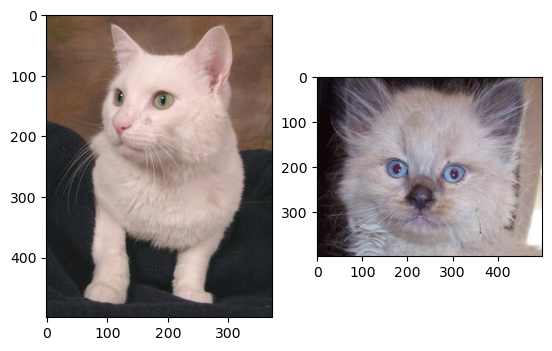

In [21]:
# 이미지 2개의 그림을 그려보아요
fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

img1 = Image.open(filenames[0])
ax1.imshow(img1)
img2 = Image.open(filenames[1])
ax2.imshow(img2)
plt.show()

TFRecord로 이미지 데이터 저장!
이미지에대한 픽셀 데이터를 추출해서 TFRecord에 저장
단, resize하지 않고 원본 그대로 저장
label도 파악해서 TFRecord에 넣을거에요. 이미지의 가로길이 세로길이도 넣을거에요
이미지 파일의 이름도 TFRecord에 넣을거에요
여러장의 이미지를 처리해야되기 때문에 함수를 만들어서 사용
함수는 이미지 1장에 대한 Example객체를 리턴하도록 작성
나중에 이미지의 수만큼 for문을 돌리면서 TFRecord에 Example객체를 write하면 되요

In [34]:
# 입력으로 들어온 이미지 1장에 대해 Example 객체를 만들어 리턴하는 함수
def to_example(filename):
    # filename. => ./data/tfrecord_cat_dog/cat.688.jpg
    image_string = tf.io.read_file(filename) # 파일내용을 문자열로 가져와요!
    image_shape = tf.io.decode_jpeg(image_string).shape #jpg으롤 변환시키는 코드 (499, 372, 3)
    label = (filename.split('/')[-1]).split('.')[0] == 'dog'

    feature = {
        'image/height': tf.train.Feature(int64_list=tf.train.Int64List(value=[image_shape[0]])),
        'image/width': tf.train.Feature(int64_list=tf.train.Int64List(value=[image_shape[1]])),
        'image/label': tf.train.Feature(int64_list=tf.train.Int64List(value=[label])),
        'image_raw': tf.train.Feature(bytes_list=tf.train.BytesList(value=[image_string.numpy()])),
        'filename': tf.train.Feature(bytes_list=tf.train.BytesList(value=[filename.encode()]))
    }
    return tf.train.Example(features=tf.train.Features(feature=feature))

result = to_example(filenames[0])
print(result)


tfrecords_path = './TFRecord_example.tfrecord'

with tf.io.TFRecordWriter(tfrecords_path) as writer:
    try:        
        tf_example = to_example(filenames[0])
        writer.write(tf_example.SerializeToString())
        tf_example = to_example(filenames[1])
        writer.write(tf_example.SerializeToString())
    except:
        print('에러 발생')



features {
  feature {
    key: "filename"
    value {
      bytes_list {
        value: "./data/tfrecord_cat_dog/cat.620.jpg"
      }
    }
  }
  feature {
    key: "image/height"
    value {
      int64_list {
        value: 499
      }
    }
  }
  feature {
    key: "image/label"
    value {
      int64_list {
        value: 0
      }
    }
  }
  feature {
    key: "image/width"
    value {
      int64_list {
        value: 372
      }
    }
  }
  feature {
    key: "image_raw"
    value {
      bytes_list {
        value: "\377\330\377\340\000\020JFIF\000\001\001\000\000\001\000\001\000\000\377\333\000C\000\n\007\007\010\007\006\n\010\010\010\013\n\n\013\016\030\020\016\r\r\016\035\025\026\021\030#\037%$\"\037\"!&+7/&)4)!\"0A149;>>>%.DIC<H7=>;\377\333\000C\001\n\013\013\016\r\016\034\020\020\034;(\"(;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;\377\300\000\021\010\001\363\001t\003\001\"\000\002\021\001\003\021\001\377\304\000\037\000\000\001\005\001\001\001\001\001\001\000\000

이렇게 이미지에 대한 여러가지 정보가 TFRecord에 저장되어 있어요
이 데이터를 불러와서 이미지를 그려보아요
Dataset을 생성해야 해요

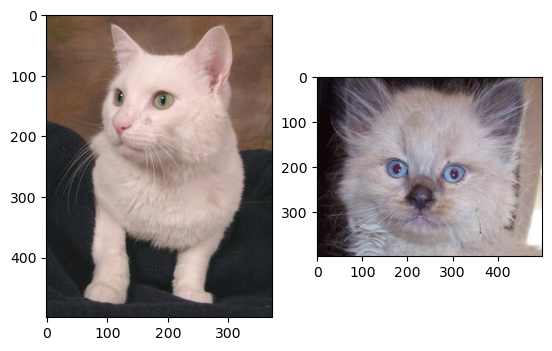

In [35]:
# Dataset을 생성해야 해요
raw_image_dataset = tf.data.TFRecordDataset(tfrecords_path)

# 데이터를 복구해야 해요!
# 만든 피처의 형태를 가져와서 아래처럼 수정
feature_description = {
        'image/height': tf.io.FixedLenFeature([],tf.int64),
        'image/width': tf.io.FixedLenFeature([],tf.int64),
        'image/label': tf.io.FixedLenFeature([],tf.int64),
        'image_raw': tf.io.FixedLenFeature([],tf.string),
        'filename': tf.io.FixedLenFeature([],tf.string)
}

def _parse_function(proto):
    return tf.io.parse_single_example(proto, feature_description)

parsed_image_dataset = raw_image_dataset.map(_parse_function,
                                             num_parallel_calls=tf.data.AUTOTUNE)

# 잘 복구가 되었는지 그림을 그려보아요~
fig = plt.figure()
axes = []

for i in range(2):
    axes.append(fig.add_subplot(1,2,i+1))

k = 0
import io

for image_feature in parsed_image_dataset:
    image_raw = image_feature['image_raw'].numpy() #byte array형태로

    decode = np.array(Image.open(io.BytesIO(image_raw)))  # 이미지에 대한 ndarray

    axes[k].imshow(decode)
    k += 1

plt.show()


위에 코드를 이용해서
전체 4000장 이미지에 대한 TFRecord를 생성한 후 이걸 이용해서 tf.data.Dateset을 만들어서
우리 모델의 입력으로 사용하는 코드를 작성해 보아요
우리의 고양이 강아지 이진분류 문제를 TFRecord + Dataset을 이용하는 코드로 변환해서 학습해 보세요!